In [4]:
# 屏蔽matplotlib字体警告，消除刷屏
import warnings

# 消除警告
warnings.filterwarnings("ignore", category=UserWarning)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # 用于3D绘图

# Windows优先顺序：微软雅黑 > 黑体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号方块

In [6]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(f"训练样本数 m = {len(x_train)}")

训练样本数 m = 2


# 绘制图像

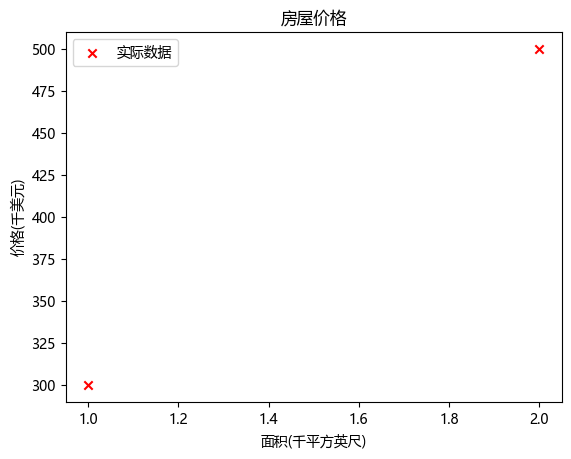

In [7]:
plt.scatter(x_train, y_train, marker='x', c='r', label='实际数据')
plt.xlabel("面积(千平方英尺)")
plt.ylabel("价格(千美元)")
plt.title('房屋价格')
plt.legend()
plt.show()

In [8]:
# 测试维度表示
# 一维
one_dimension = np.array([1, 2, 3, 4, 5, 6])  # 这是简洁写法
one_dimension2 = np.array([[1], [2], [3], [4], [5], [6]])  # 这是完整写法
two_dimension = np.array([[1, 2, 3], [4, 5, 6]])  # 这是二维数组
print(one_dimension.shape)
print(one_dimension2.shape)
print(two_dimension.shape)

(6,)
(6, 1)
(2, 3)


# 模型预测函数predict(循环)

In [ ]:
# 模型预测函数predict(循环)
def predict(x,w,b):
    """
    计算线性模型的预测值
    x: 一维数组，包含 m 个样本
    w, b: 标量参数
    返回: 一维数组，每个样本的预测值
    """
    m = x.shape[0]
    f_wb = np.zeros(m) # 初始化预测值数组,m个元素全为0
    for i in range(m):
        f_wb[i] = w*x[i]+b
    return f_wb

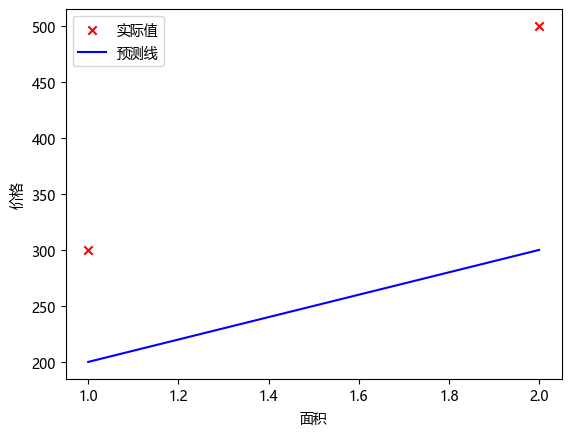

In [10]:
w = 100
b = 100
f_wb = predict(x_train, w, b)

plt.scatter(x_train, y_train, marker="x", c="r", label="实际值")
plt.plot(x_train, f_wb, c="b", label="预测线")
plt.xlabel("面积")
plt.ylabel("价格")
plt.legend()
plt.show()

# 代价函数compute_cost

In [11]:
# 代价函数compute_cost
def compute_cost(x, y, w, b):
    """
    计算线性回归的代价函数
    x: 输入特征 (m,)
    y: 真实目标 (m,)
    w, b: 模型参数
    返回: 标量代价
    """
    m = x.shape[0]  # 样本数
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost_sum += (f_wb - y[i]) ** 2
    cost = cost_sum / (2 * m)
    return cost

In [12]:
# 测试代价函数
cost = compute_cost(x_train, y_train, w, b)
print(f"代价 J = {cost:.2f}")

代价 J = 12500.00


### 生成网格数据,3D曲面+等高线

In [ ]:
w_vals = np.linspace(-100, 500, 60)  # 60个点，范围从-100到500
b_vals = np.linspace(-200, 400, 60)
W, B = np.meshgrid(w_vals, b_vals)  # 生成网格矩阵

In [14]:
Z = np.zeros_like(W)  # 形状 (60,60)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])

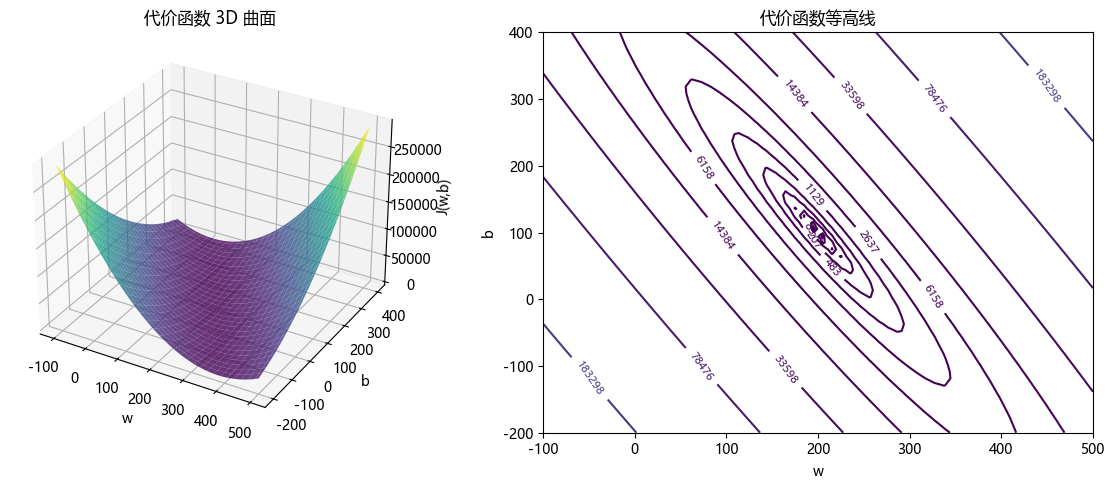

In [17]:
# 创建画布,宽12,高5
fig = plt.figure(figsize=(12, 5))

# 左侧子图,3D曲面图
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(W, B, Z, cmap="viridis", alpha=0.8, edgecolor="none")
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_zlabel("J(w,b)")
ax1.set_title("代价函数 3D 曲面")

ax2 = fig.add_subplot(122)
# 使用对数间隔的等高线，便于看到低谷
levels = np.logspace(-1, 6, 20)  # 从0.1到1e6的对数间隔
contour = ax2.contour(W, B, Z, levels=levels, cmap="viridis")
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel("w")
ax2.set_ylabel("b")
ax2.set_title("代价函数等高线")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>